In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('csv_files/response_clean.csv')
df .head()

,timestamp,year,program,beh_daily_use,beh_time_spent,beh_attendance,hours_per_week_raw,pu_useful,pu_efficiency,il_enjoyment,...,srl_strategy,srl_organize,srl_review,srl_persist,srl_evaluate,open_frustration,open_feature_request,open_srs_usage,hours_per_week_num,hours_bucket
0,9/6/2026 14:45,3rd,BSc Physics,3,3,2,12-Oct,3,3,3,...,4,4,4,3,4,Subscriptions,A feature to show what one should already know...,Decent,11.0,11-20
1,9/6/2026 15:00,3rd,BIT,4,4,2,20hrs,5,4,4,...,4,5,4,4,4,to pay,QNA,No,20.0,20+
2,9/6/2026 15:05,3rd,BIT,3,4,4,5,4,4,4,...,3,4,4,4,4,Giving short answers,Organizing my research,It helps in revising my study,5.0,6-10
3,9/6/2026 15:21,3rd,BIT,3,3,3,48 hrs,2,4,3,...,3,5,4,4,3,There unnecessary extra answers,Easier prompt to get enough required answer,No,48.0,20+
4,9/6/2026 16:22,3rd,BIT,3,3,1,12-Oct,2,3,2,...,2,3,2,2,2,Distraction,Idk,No,11.0,11-20


In [2]:
df.columns = df.columns.str.strip()

### Computing scores per respondents

In [3]:
df['behavioral_avg'] = df[['beh_daily_use', 'beh_time_spent', 'beh_attendance']].mean(axis = 1)
df['pu_avg'] = df[['pu_useful', 'pu_efficiency']].mean(axis=1)
df['interest_avg'] = df[['il_enjoyment', 'il_curiosity', 'em_connection']].mean(axis=1)
df['intention_avg'] = df[['biu_intention', 'biu_voluntary']].mean(axis=1)
df['srl_avg'] = df[['srl_strategy', 'srl_organize', 'srl_review', 'srl_persist', 'srl_evaluate']].mean(axis=1)

### Descriptive statistics of every new columns

In [4]:
constructs = ['behavioral_avg', 'pu_avg', 'interest_avg', 'intention_avg', 'srl_avg']

df[constructs].agg(['mean', 'std', 'min', 'max']).round(2)

,behavioral_avg,pu_avg,interest_avg,intention_avg,srl_avg
mean,2.98,3.47,3.46,3.66,3.61
std,0.91,0.96,0.82,1.19,0.78
min,1.67,2.00,1.67,1.00,2.00
max,5.00,5.00,5.00,5.00,4.60


##### Finding

Behavioural engagement is the weakest dimension (mean = 2.98), and it's dragged down by one item. "I regularly attend classes and actively participate" scored 2.35 by far the lowest item in the whole survey. Tool usage items scored fine (3.35, 3.24). So the gap isn't that students don't use tools; it's classroom participation.

### Ranking individual items to see the weak points

In [5]:
# sorting from lowest to highest
likert_items = ['beh_daily_use', 'beh_time_spent', 'beh_attendance',
                'pu_useful', 'pu_efficiency',
                'il_enjoyment', 'il_curiosity', 'em_connection',
                'biu_intention', 'biu_voluntary',
                'srl_strategy', 'srl_organize', 'srl_review', 'srl_persist', 'srl_evaluate']

df[likert_items].mean().sort_values().round(2)

beh_attendance    2.31
em_connection     3.06
beh_time_spent    3.25
pu_efficiency     3.31
beh_daily_use     3.38
srl_review        3.38
srl_persist       3.50
il_enjoyment      3.50
srl_strategy      3.56
pu_useful         3.62
biu_intention     3.62
srl_evaluate      3.69
biu_voluntary     3.69
il_curiosity      3.81
srl_organize      3.94
dtype: float64

#### Weakest items

- `beh_attendance` = 2.31, the lowest score in your entire survey. Students rate their class attendance/participation notably poorly, well below the neutral midpoint of 3 proving the finding mentioned above.

- `em_connection` = 3.06, barely above neutral. Students don't feel connected to instructors/peers through digital tools.

- `beh_time_spent` = 3.25, weakest engagement item after attendance.

#### Strongest items

- `srl_organize` = 3.94, students are best at organising their time/materials in advance. (strongest finding)

- `il_curiosity` = 3.81, students are curious about exploring new tool features.


### Checking correlation between constructs.

In [6]:
df[constructs].corr().round(2)

,behavioral_avg,pu_avg,interest_avg,intention_avg,srl_avg
behavioral_avg,1.00,0.74,0.68,0.58,0.70
pu_avg,0.74,1.00,0.69,0.59,0.69
interest_avg,0.68,0.69,1.00,0.78,0.72
intention_avg,0.58,0.59,0.78,1.00,0.91
srl_avg,0.70,0.69,0.72,0.91,1.00


### Findings

- `intention_avg` × `srl_avg` = 0.91 — very strong. Students who intend to keep using digital tools also report much higher self-regulation. The strongest correlation on the matrix.

- `interest_avg` × `srl_avg` = 0.72 — also strong, supporting the "interest → SRL" link from the TAM/SRL paper.

- `behavioral_avg` × `srl_avg` = 0.70 — actual usage tracking with self-regulation, mirroring the paper's ASU→SRL relationship.

#### Limitation

Given the small sample (n=17), correlations should be interpreted as exploratory; the uniformly high values across all construct pairs likely reflect limited sample size rather than precise measurement of distinct relationships.

#### Looking at count of key variables

In [7]:
key_items= ['beh_attendance', 'srl_review', 'biu_voluntary', 'il_curiosity']

for item in key_items:
    print(df[item].value_counts().sort_index())

beh_attendance
1    5
2    5
3    3
4    2
5    1
Name: count, dtype: int64
srl_review
2    3
3    5
4    7
5    1
Name: count, dtype: int64
biu_voluntary
1    1
2    3
3    2
4    4
5    6
Name: count, dtype: int64
il_curiosity
1    1
2    1
3    2
4    8
5    4
Name: count, dtype: int64


#### Thematic coding

In [8]:
open_cols = ['open_frustration', 'open_feature_request', 'open_srs_usage']

for col in open_cols:
    print(f"=== {col} ===")
    for i, val in df[col].items():
        print(i, '.', val)
    print()

=== open_frustration ===
0 . Subscriptions
1 . to pay 
2 . Giving short answers 
3 . There unnecessary extra answers 
4 . Distraction
5 . Math bujau na sakdaina majale
6 . Contradicting and inconsistant answers 
7 . limited token 
8 . Token limit 
9 . Wasting time fixing clunky configurations, environment errors instead of coding, outdated documentation & heavy tools that slow down my laptop.
10 . Not able to ask doubt
11 . expensive
12 . The biggest frustration is that digital learning often feels boring and passive. I don’t feel actively engaged while learning.
13 . Not at all
14 . Ads
15 . Subscription, 

=== open_feature_request ===
0 . A feature to show what one should already know beforehand before starting a topic.
1 . QNA
2 . Organizing my research 
3 . Easier prompt to get enough required answer
4 . Idk
5 . Proper mathematical solution dine
6 . I wold kill for smthing that will force me to study 💯 facts 
7 . Hypothetical Study Feature
8 . Sharing seamlessly 
9 . 1.AI assistant

In [9]:
df.loc[0, 'frustration_theme'] = 'cost'
df.loc[1, 'frustration_theme'] = 'cost'
df.loc[2, 'frustration_theme'] = 'ai_quality'
df.loc[3, 'frustration_theme'] = 'ai_quality'
df.loc[4, 'frustration_theme'] = 'passive_boring'
df.loc[5, 'frustration_theme'] = 'ai_quality'
df.loc[6, 'frustration_theme'] = 'ai_quality'
df.loc[7, 'frustration_theme'] = 'ai_quality'
df.loc[8, 'frustration_theme'] = 'ai_quality'
df.loc[9, 'frustration_theme'] = 'technical'
df.loc[10, 'frustration_theme'] = 'passive_boring'
df.loc[11, 'frustration_theme'] = 'cost'
df.loc[12, 'frustration_theme'] = 'passive_boring'
df.loc[13, 'frustration_theme'] = 'none'
df.loc[14, 'frustration_theme'] = 'cost'
df.loc[15, 'frustration_theme'] = 'cost'

In [10]:
df['frustration_theme'].value_counts()

frustration_theme
ai_quality        6
cost              5
passive_boring    3
technical         1
none              1
Name: count, dtype: int64

In [11]:
theme_map = {
    0: 'personalization_scheduling', 1: 'interactive_qna', 2: 'content_organization',
    3: 'ai_response_quality', 4: 'none', 5: 'ai_response_quality',
    6: 'accountability_reminders', 7: 'none', 8: 'sharing_collaboration',
    9: 'accountability_reminders',  
    10: 'interactive_qna', 11: 'cost_access', 12: 'gamification_engagement',
    13: 'none', 14: 'interactive_qna', 15: 'personalization_scheduling'
}

df['feature_request_theme'] = df.index.map(theme_map)
df['feature_request_theme'].value_counts()

feature_request_theme
interactive_qna               3
none                          3
personalization_scheduling    2
ai_response_quality           2
accountability_reminders      2
content_organization          1
sharing_collaboration         1
cost_access                   1
gamification_engagement       1
Name: count, dtype: int64

In [12]:
usage_map = {
    0: 'yes', 1: 'no', 2: 'yes', 3: 'no', 4: 'no', 5: 'no',
    6: 'plan_to', 7: 'unclear', 8: 'no', 9: 'yes', 10: 'no',
    11: 'yes', 12: 'no', 13: 'no', 14: 'yes', 15: 'yes'
}

df['srs_usage_label'] = df.index.map(usage_map)
df['srs_usage_label'].value_counts()

srs_usage_label
no         8
yes        6
plan_to    1
unclear    1
Name: count, dtype: int64

##### Students are not primarily disengaged from digital learning because tools are boring (only 19% of frustrations), they are disengaged because the tools they rely on (largely external AI assistants and paid apps) are costly and inconsistent (69% of frustrations combined). Half the surveyed class has never used a spaced repetition tool, yet feature requests for personalized scheduling and accountability mechanisms emerged independently and without prompting directly anticipating the proposed prototype.

### Vizualizing the findings

In [18]:
df['program'].value_counts()

program
BIT            12
BSc Physics     2
BSc CSIT        2
Name: count, dtype: int64

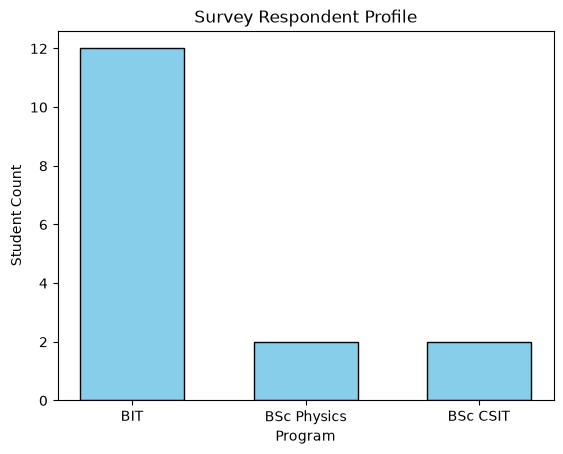

In [23]:
programs = ['BIT', 'BSc Physics', 'BSc CSIT']
count = df['program'].value_counts()

plt.bar(programs, count,  color='skyblue', edgecolor='black', width=0.6)
plt.title('Survey Respondent Profile')
plt.xlabel('Program')
plt.ylabel('Student Count')
plt.savefig('pictures/chart0_survey_respondent_profile.jpg', dpi=300)
plt.show()

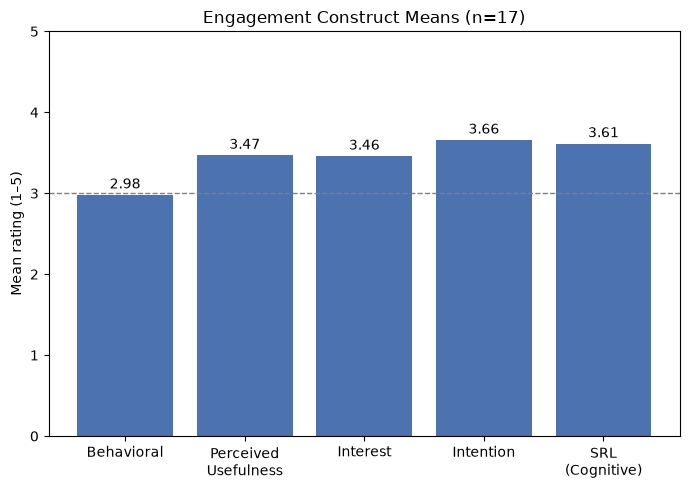

In [13]:
constructs = ['behavioral_avg', 'pu_avg', 'interest_avg', 'intention_avg', 'srl_avg']
labels = ['Behavioral', 'Perceived\nUsefulness', 'Interest', 'Intention', 'SRL\n(Cognitive)']
means = df[constructs].mean()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, means, color='#4C72B0')
ax.set_ylim(0, 5)
ax.set_ylabel('Mean rating (1–5)')
ax.set_title('Engagement Construct Means (n=17)')
ax.axhline(3, color='gray', linestyle='--', linewidth=1)  # neutral midpoint
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.08, f'{val:.2f}', ha='center')
plt.tight_layout()
plt.savefig('pictures/chart1_construct_means.jpg', dpi=300)
plt.show()

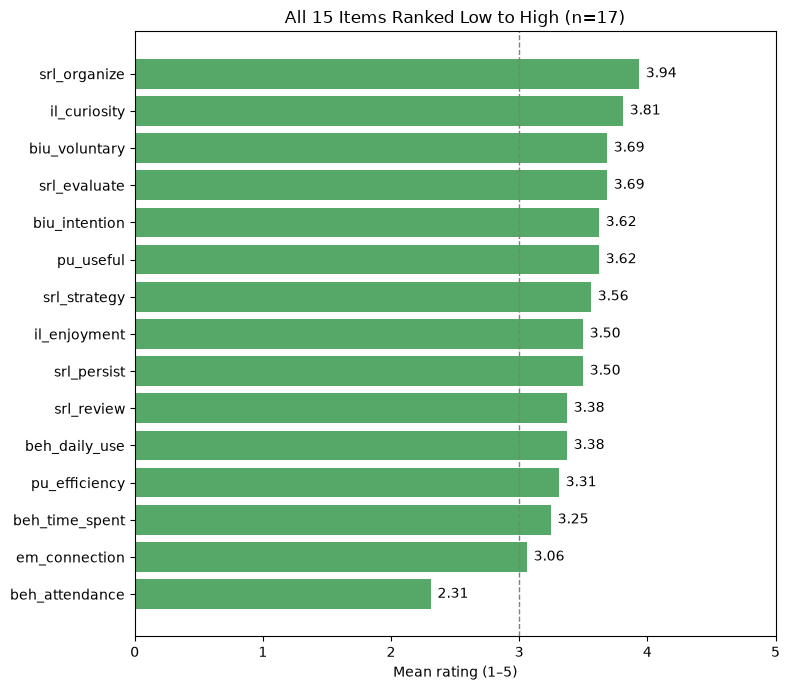

In [14]:
likert_items = ['beh_daily_use', 'beh_time_spent', 'beh_attendance',
                'pu_useful', 'pu_efficiency',
                'il_enjoyment', 'il_curiosity', 'em_connection',
                'biu_intention', 'biu_voluntary',
                'srl_strategy', 'srl_organize', 'srl_review', 'srl_persist', 'srl_evaluate']
item_means = df[likert_items].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(item_means.index, item_means.values, color='#55A868')
ax.set_xlim(0, 5)
ax.set_xlabel('Mean rating (1–5)')
ax.set_title('All 15 Items Ranked Low to High (n=17)')
ax.axvline(3, color='gray', linestyle='--', linewidth=1)
for i, val in enumerate(item_means.values):
    ax.text(val + 0.05, i, f'{val:.2f}', va='center')
plt.tight_layout()
plt.savefig('pictures/chart2_item_ranking.jpg', dpi=300)
plt.show()

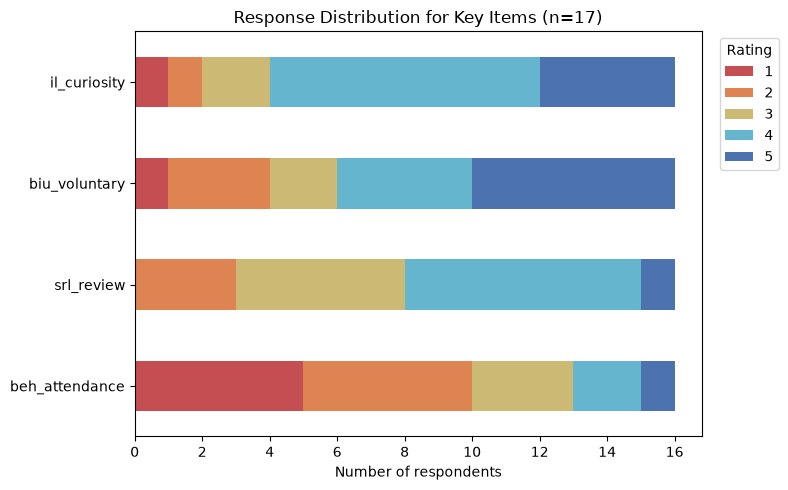

In [15]:
key_items = ['beh_attendance', 'srl_review', 'biu_voluntary', 'il_curiosity']
dist = pd.DataFrame({item: df[item].value_counts().sort_index() for item in key_items}).fillna(0).T
dist = dist.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
dist.plot(kind='barh', stacked=True, ax=ax,
          color=['#C44E52', '#DD8452', '#CCB974', '#64B5CD', '#4C72B0'])
ax.set_xlabel('Number of respondents')
ax.set_title('Response Distribution for Key Items (n=17)')
ax.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pictures/chart3_distribution.jpg', dpi=300)
plt.show()

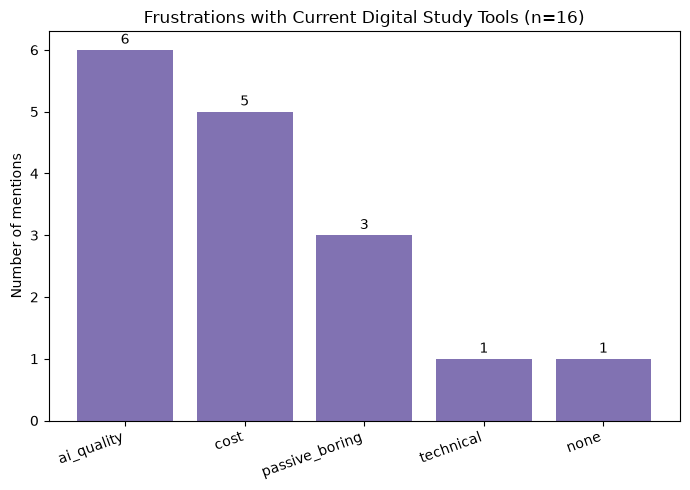

In [16]:
theme_counts = df['frustration_theme'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(theme_counts.index, theme_counts.values, color='#8172B2')
ax.set_ylabel('Number of mentions')
ax.set_title('Frustrations with Current Digital Study Tools (n=16)')
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, theme_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, str(val), ha='center')
plt.tight_layout()
plt.savefig('pictures/chart4_frustration_themes.jpg', dpi=300)
plt.show()